In [ ]:
!pip install timm

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/real_and_fake_face"

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'exp 5.pdf', 'manage.py', 'db.sqlite3', 'main.gsheet', 'sample_submission.gsheet', 'Untitled document (5).gdoc', 'assingment new.gdoc', 'Untitled document (4).gdoc', '40kwInverter.xlsx', 'Untitled spreadsheet.gsheet', 'Untitled document (3).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'archive (4)']


In [ ]:
!unzip "/content/drive/MyDrive/real_and_fake_face.zip" -d "/content/dataset"

unzip:  cannot find or open /content/drive/MyDrive/real_and_fake_face.zip, /content/drive/MyDrive/real_and_fake_face.zip.zip or /content/drive/MyDrive/real_and_fake_face.zip.ZIP.


In [ ]:
dataset_path = "/content/drive/MyDrive/archive (4)"

In [ ]:
import os
print(os.listdir(dataset_path))

['real_and_fake_face', 'real_and_fake_face_detection']


In [ ]:
print(os.listdir(dataset_path + "/real_and_fake_face"))

['training_real', 'training_fake']


In [ ]:
import shutil
import os
base_dir = "/content/faces_dataset"
real_dir = os.path.join(base_dir, "real")
fake_dir = os.path.join(base_dir, "fake")
os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)
source_real = dataset_path + "/real_and_fake_face/training_real"
source_fake = dataset_path + "/real_and_fake_face/training_fake"
for file in os.listdir(source_real):
    shutil.copy(os.path.join(source_real, file), real_dir)
for file in os.listdir(source_fake):
    shutil.copy(os.path.join(source_fake, file), fake_dir)
print("Dataset organized successfully")

Dataset organized successfully


In [ ]:
from torch.utils.data import random_split
full_dataset = datasets.ImageFolder(base_dir, transform=train_transform)
print(full_dataset.classes)
print("Total Images:", len(full_dataset))

['fake', 'real']
Total Images: 2041


In [ ]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))
print("Test Size:", len(test_dataset))

Train Size: 1428
Validation Size: 306
Test Size: 307


In [ ]:
class ChannelAttention(nn.Module):

    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))

        out = avg_out + max_out

        return self.sigmoid(out)


class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=kernel_size//2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(x, dim=1, keepdim=True)

        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg_out, max_out], dim=1)

        x = self.conv(x)

        return self.sigmoid(x)


class CBAM(nn.Module):

    def __init__(self, channels):
        super(CBAM, self).__init__()

        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):

        x = x * self.ca(x)

        x = x * self.sa(x)

        return x

In [ ]:
class DeepFakeDetector(nn.Module):

    def __init__(self):
        super(DeepFakeDetector, self).__init__()

        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=0
        )

        self.cbam = CBAM(1280)

        self.classifier = nn.Sequential(

            nn.Linear(1280, 512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512, 2)
        )

    def forward(self, x):

        x = self.backbone.forward_features(x)

        x = self.cbam(x)

        x = nn.functional.adaptive_avg_pool2d(x, 1)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DeepFakeDetector().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

cuda


In [ ]:
EPOCHS = 5

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}')

    print(f'Train Loss: {train_loss:.4f}')

    print(f'Validation Loss: {val_loss:.4f}')

100%|██████████| 45/45 [00:25<00:00,  1.74it/s]


Epoch 1/5
Train Loss: 0.6744
Validation Loss: 0.6245


100%|██████████| 45/45 [00:22<00:00,  1.97it/s]


Epoch 2/5
Train Loss: 0.5417
Validation Loss: 0.5391


100%|██████████| 45/45 [00:22<00:00,  1.96it/s]


Epoch 3/5
Train Loss: 0.3401
Validation Loss: 0.5616


100%|██████████| 45/45 [00:23<00:00,  1.95it/s]


Epoch 4/5
Train Loss: 0.1998
Validation Loss: 0.6024


100%|██████████| 45/45 [00:23<00:00,  1.95it/s]


Epoch 5/5
Train Loss: 0.1417
Validation Loss: 0.7055


In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.71      0.71       139
           1       0.76      0.77      0.77       168

    accuracy                           0.74       307
   macro avg       0.74      0.74      0.74       307
weighted avg       0.74      0.74      0.74       307



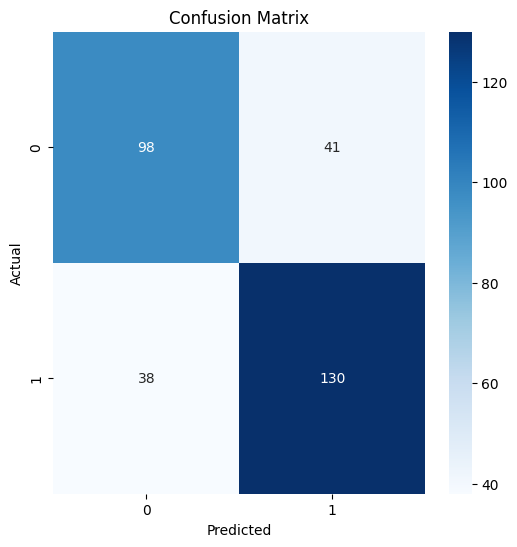

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [ ]:
torch.save(model.state_dict(), "deepfake_detector.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("deepfake_detector.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image

classes = ['fake', 'real']

def predict_image(image_path):

    image = Image.open(image_path).convert('RGB')

    image = val_transform(image)

    image = image.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(image)

        _, pred = torch.max(output, 1)

    print("Prediction:", classes[pred.item()])

In [ ]:
def predict_and_show(image_path):

    image = Image.open(image_path).convert('RGB')

    plt.imshow(image)
    plt.axis('off')

    transformed = val_transform(image)

    transformed = transformed.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(transformed)

        _, pred = torch.max(output, 1)

    plt.title(f'Prediction: {classes[pred.item()]}')

    plt.show()

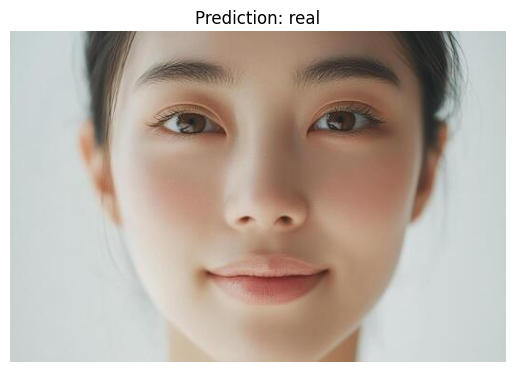

Prediction: real


In [ ]:
predict_and_show('/content/test.jpg')
predict_image('/content/test.jpg')

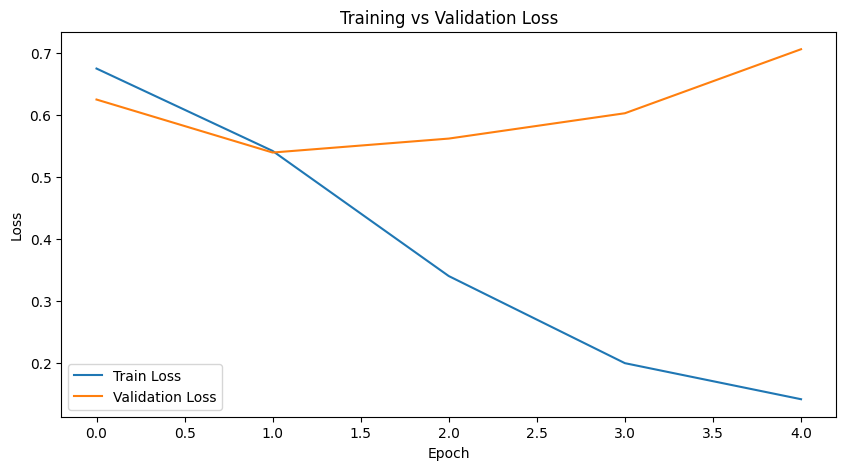

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 28.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=e0a2785b62979a32a4b7ff25d3de0ee01ebca87d186c6bdd640274415fc4ec9e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import cv2
import numpy as np

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
target_layer = model.backbone.conv_head

In [ ]:
cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

In [ ]:
from PIL import Image

def visualize_gradcam(image_path):

    image = Image.open(image_path).convert('RGB')

    image_resized = image.resize((224,224))

    rgb_img = np.array(image_resized).astype(np.float32) / 255.0

    input_tensor = val_transform(image_resized).unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.show()

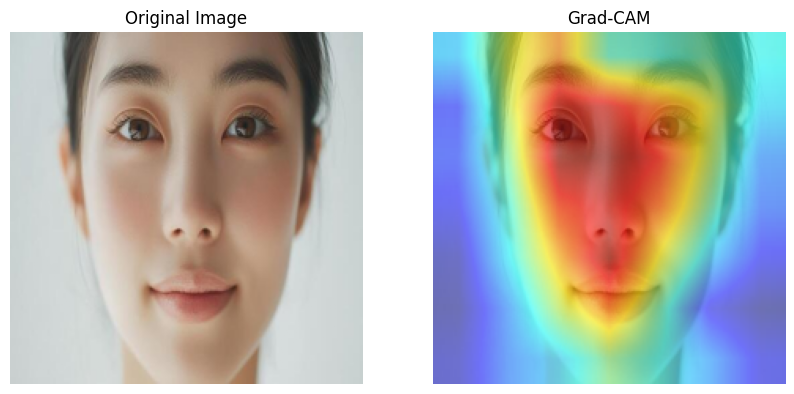

RED/YELLOW REGION - HIGH ACTIVATION
BLUE/GREEN REGION - LOW ACTIVATION


In [ ]:
visualize_gradcam('/content/test.jpg')
print('RED/YELLOW REGION - HIGH ACTIVATION')
print('BLUE/GREEN REGION - LOW ACTIVATION')

In [1]:
!jupyter nbconvert --ClearOutputPreprocessor.enabled=True --inplace *.ipynb

[NbConvertApp] WARNING | pattern '*.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute t